In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

In [3]:
!pip install openexr Imath numpy matplotlib
# !pip install opencv-python-headless
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00


In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt
import OpenEXR
import Imath

def read_exr(path):
    exr = OpenEXR.InputFile(path)
    header = exr.header()

    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    r = np.frombuffer(exr.channel('R', FLOAT), dtype=np.float32)
    g = np.frombuffer(exr.channel('G', FLOAT), dtype=np.float32)
    b = np.frombuffer(exr.channel('B', FLOAT), dtype=np.float32)

    r = r.reshape(height, width)
    g = g.reshape(height, width)
    b = b.reshape(height, width)

    img = np.stack([r, g, b], axis=0)  # CHW

    return img

In [5]:
img = cv2.imread("/content/drive/MyDrive/469_data/room3/25136394-08192spp.exr", cv2.IMREAD_UNCHANGED)
print(img is None)

False


In [6]:
class MonteCarloDataset(Dataset):
    def __init__(self, root_dirs, patch_size=128):
        self.pairs = []
        self.patch_size = patch_size

        for root in root_dirs:
            files = os.listdir(root)

            for f in files:
                if "00128spp.exr" in f:
                    base = f.split("-00128spp.exr")[0]
                    clean_name = base + "-08192spp.exr"

                    noisy_path = os.path.join(root, f)
                    clean_path = os.path.join(root, clean_name)

                    if os.path.exists(clean_path):
                        self.pairs.append((noisy_path, clean_path))

        print("Total pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]

        noisy = read_exr(noisy_path)
        clean = read_exr(clean_path)

        C, H, W = noisy.shape
        ps = self.patch_size

        top = np.random.randint(0, H - ps)
        left = np.random.randint(0, W - ps)

        noisy = noisy[:, top:top+ps, left:left+ps]
        clean = clean[:, top:top+ps, left:left+ps]

        noisy = torch.from_numpy(noisy)
        clean = torch.from_numpy(clean)

        return noisy, clean

In [7]:
train_dataset = MonteCarloDataset([
    "/content/drive/MyDrive/469_data/room2",
    "/content/drive/MyDrive/469_data/room3"
])

Total pairs: 388


In [8]:
test_dataset = MonteCarloDataset([
    "/content/drive/MyDrive/469_data/car2"
])

Total pairs: 180


In [9]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

In [10]:
from kpcn_model import KPCN

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KPCN().to(device)

In [11]:
import torch.nn.functional as F

def compute_psnr(output, target):
    mse = F.mse_loss(output, target)
    psnr = -10 * torch.log10(mse)
    return psnr.item()

In [12]:
from skimage.metrics import structural_similarity as ssim

def compute_ssim(output, target):

    out_np = output.squeeze().permute(1,2,0).cpu().numpy()
    target_np = target.squeeze().permute(1,2,0).cpu().numpy()

    score = ssim(out_np, target_np, channel_axis=2, data_range=1.0)

    return score


def compute_variance(tensor):
    return torch.var(tensor).item()

In [13]:
# =========================
# TRAIN 10 EPOCHS
# =========================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.L1Loss()

epochs = 20

train_losses = []
train_psnr = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_psnr = 0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)

        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(output, clean)

    avg_loss = total_loss / len(train_loader)
    avg_psnr = total_psnr / len(train_loader)

    train_losses.append(avg_loss)
    train_psnr.append(avg_psnr)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} PSNR: {avg_psnr:.2f} dB")

    if (epoch + 1) % 3 == 0:
        checkpoint_path = f"/content/drive/MyDrive/kpcn_checkpoint_epoch_{epoch+1}.pt"

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }, checkpoint_path)

        print(f"Checkpoint saved at epoch {epoch+1}")

Epoch [1/20] Loss: 0.4671 PSNR: 6.25 dB
Epoch [2/20] Loss: 0.4677 PSNR: 7.08 dB
Epoch [3/20] Loss: 0.2567 PSNR: 9.38 dB
Checkpoint saved at epoch 3
Epoch [4/20] Loss: 0.3657 PSNR: 7.98 dB
Epoch [5/20] Loss: 0.2832 PSNR: 9.55 dB
Epoch [6/20] Loss: 0.3536 PSNR: 8.74 dB
Checkpoint saved at epoch 6
Epoch [7/20] Loss: 0.1173 PSNR: 13.29 dB
Epoch [8/20] Loss: 0.1295 PSNR: 12.05 dB
Epoch [9/20] Loss: 0.1107 PSNR: 13.06 dB
Checkpoint saved at epoch 9
Epoch [10/20] Loss: 0.1429 PSNR: 12.59 dB
Epoch [11/20] Loss: 0.1375 PSNR: 14.17 dB
Epoch [12/20] Loss: 0.2002 PSNR: 12.65 dB
Checkpoint saved at epoch 12
Epoch [13/20] Loss: 0.1352 PSNR: 13.13 dB
Epoch [14/20] Loss: 0.1072 PSNR: 14.97 dB
Epoch [15/20] Loss: 0.1769 PSNR: 12.07 dB
Checkpoint saved at epoch 15
Epoch [16/20] Loss: 0.0836 PSNR: 15.87 dB
Epoch [17/20] Loss: 0.1588 PSNR: 13.94 dB
Epoch [18/20] Loss: 0.1364 PSNR: 14.11 dB
Checkpoint saved at epoch 18
Epoch [19/20] Loss: 0.1106 PSNR: 14.44 dB
Epoch [20/20] Loss: 0.1372 PSNR: 14.84 dB


In [14]:
# Save model
torch.save(model.state_dict(), "/content/drive/MyDrive/kpcn_model.pt")
print("Final model saved!")

Final model saved!


In [15]:
# checkpoint = torch.load("/content/drive/MyDrive/kpcn_checkpoint_epoch_6.pt")

# model = KPCN().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch']

# print(f"Resuming from epoch {start_epoch}")

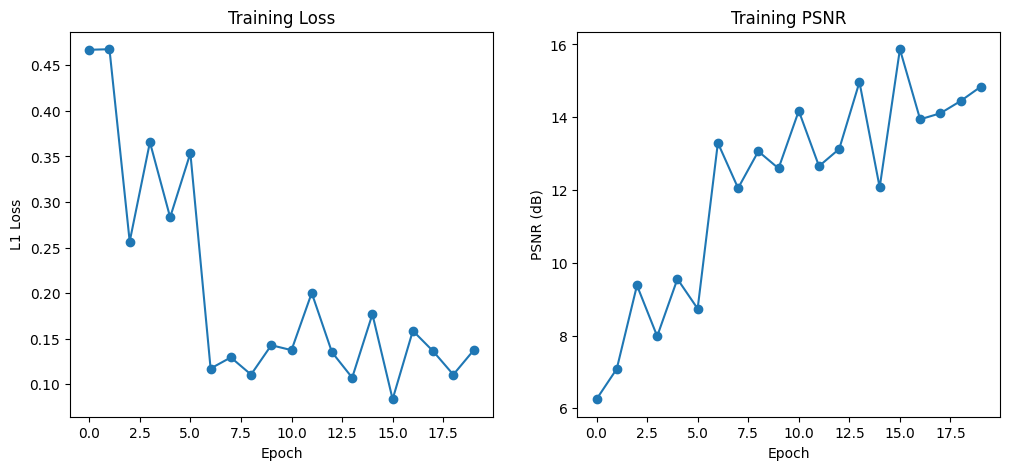

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")

# PSNR curve
plt.subplot(1,2,2)
plt.plot(train_psnr, marker='o')
plt.title("Training PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")

plt.show()

In [17]:
# =============================
# EVALUATE TEST PERFORMANCE
# =============================

# model.load_state_dict(torch.load("/content/drive/MyDrive/kpcn_model.pt"))
# model.eval()

# print("Model loaded!")

model.eval()

total_psnr = 0
total_ssim = 0
total_noisy_var = 0
total_denoised_var = 0
count = 0

with torch.no_grad():

    for noisy, clean in test_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        psnr = compute_psnr(output, clean)
        ssim_score = compute_ssim(output, clean)

        noisy_var = compute_variance(noisy)
        denoised_var = compute_variance(output)

        total_psnr += psnr
        total_ssim += ssim_score
        total_noisy_var += noisy_var
        total_denoised_var += denoised_var

        count += 1

avg_psnr = total_psnr / count
avg_ssim = total_ssim / count
avg_noisy_var = total_noisy_var / count
avg_denoised_var = total_denoised_var / count

print("Average Test PSNR:", avg_psnr, "dB")
print("Average Test SSIM:", avg_ssim)
print("Average Noisy Variance:", avg_noisy_var)
print("Average Denoised Variance:", avg_denoised_var)
print("Variance Reduction:", avg_noisy_var - avg_denoised_var)

Average Test PSNR: 37.531859539614786 dB
Average Test SSIM: 0.9467759
Average Noisy Variance: 64.52707740777926
Average Denoised Variance: 49.99888853912224
Variance Reduction: 14.528188868657018


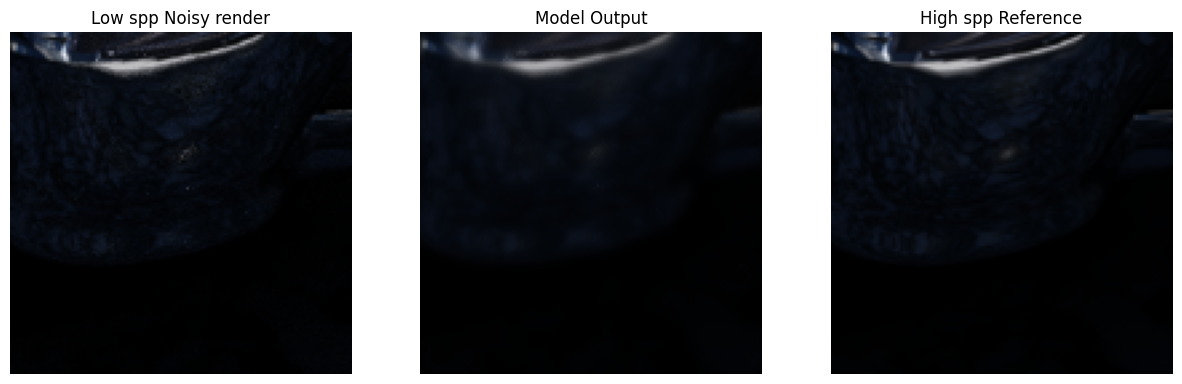

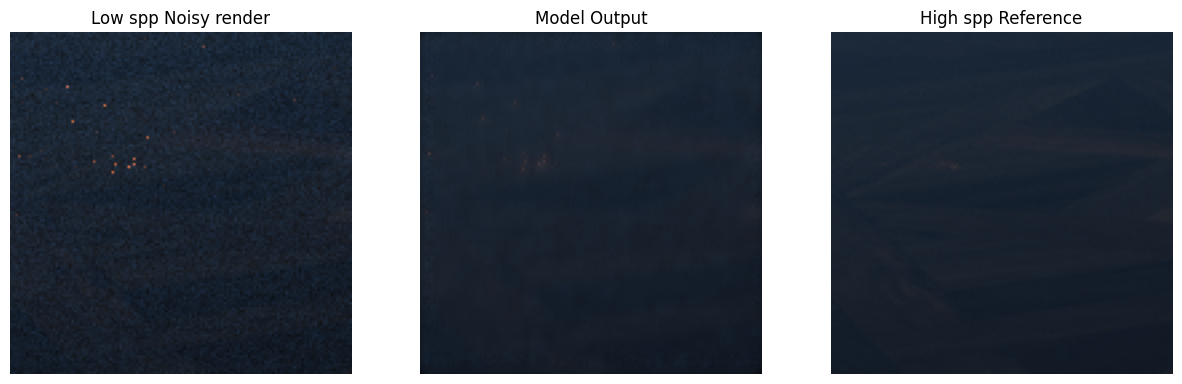

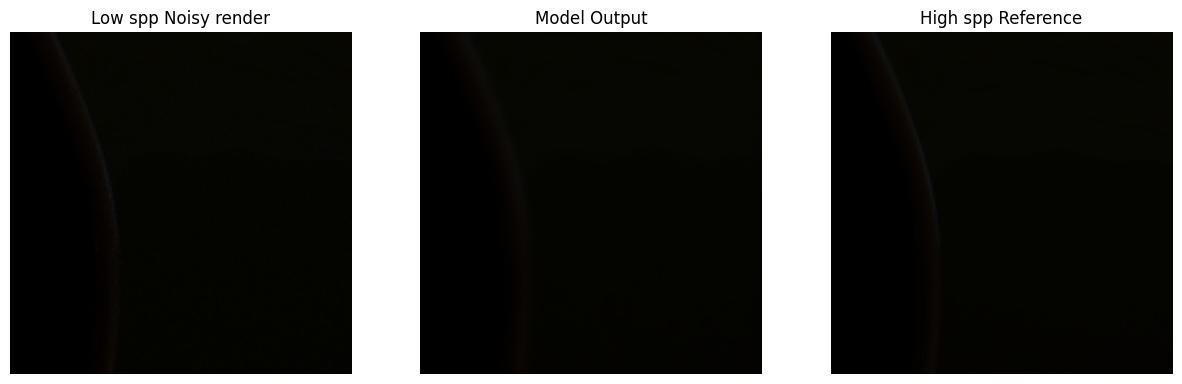

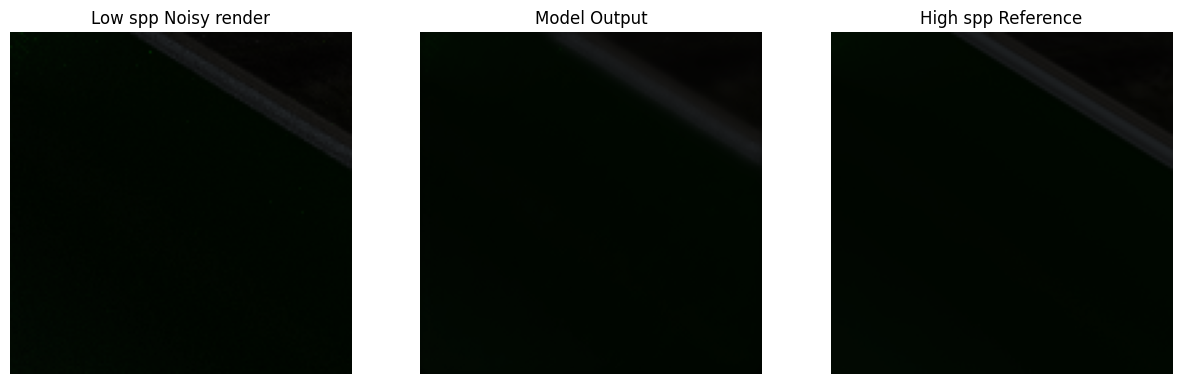

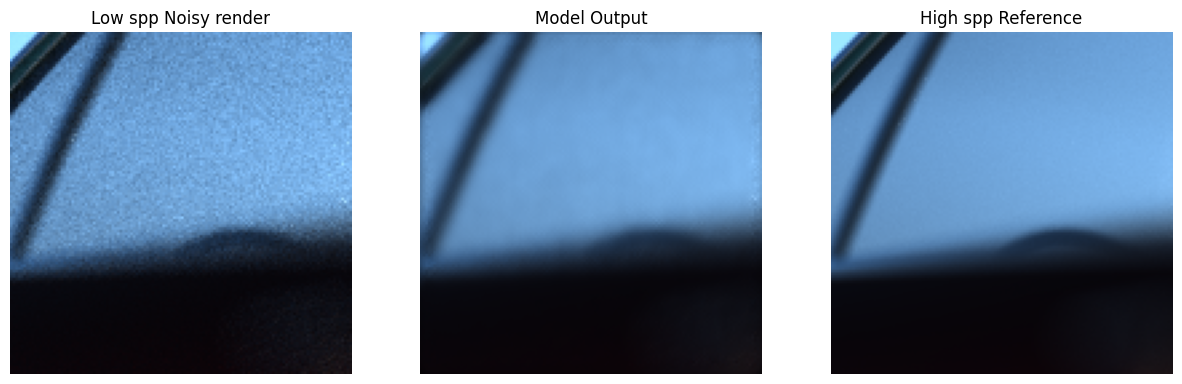

In [18]:
# =========================
# VISUALIZE RESULTS
# =========================

model.eval()
num_samples = 5
with torch.no_grad():
    for i, (noisy, clean) in enumerate(test_loader):
        if i >= num_samples:
            break
        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        # Convert tensors to numpy
        noisy_np = noisy.squeeze(0).permute(1,2,0).cpu().numpy()
        clean_np = clean.squeeze(0).permute(1,2,0).cpu().numpy()
        out_np = output.squeeze(0).permute(1,2,0).cpu().numpy()

        # Clip for display
        noisy_np = np.clip(noisy_np, 0, 1)
        clean_np = np.clip(clean_np, 0, 1)
        out_np = np.clip(out_np, 0, 1)

        import matplotlib.pyplot as plt

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.title("Low spp Noisy render")
        plt.imshow(noisy_np)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Model Output")
        plt.imshow(out_np)
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("High spp Reference")
        plt.imshow(clean_np)
        plt.axis("off")

        plt.show()

In [19]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# for i in range(100):
#     optimizer.zero_grad()
#     output = model(noisy)
#     loss = torch.nn.functional.l1_loss(output, clean)
#     loss.backward()
#     optimizer.step()

#     if i % 20 == 0:
#         print(i, loss.item())